In [1]:
import pandas as pd
from tqdm import tqdm
import time

In [2]:
df_true = pd.read_csv('./splits/midwest-big-train.csv')

In [3]:
def proportional_sample(df, col_name, sample_size):
    value_counts = df[col_name].value_counts(normalize=True)
    sampled_counts = (value_counts * sample_size).round().astype(int)

    sampled_dfs = []
    for value, count in sampled_counts.items():
        subset = df[df[col_name] == value].sample(n=min(count, len(df[df[col_name] == value])), replace=False) #sample without replacement, take the minimum of the count or the amount of that value in the df.
        sampled_dfs.append(subset)

    sampled_df = pd.concat(sampled_dfs)
    return sampled_df

## Take a proportional slice of the text to practice with

sample_size = 50000
df = proportional_sample(df_true, 'rating', sample_size)

In [4]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

def pnn(n):
    if n in {1,2}: return 0
    elif n in {3,4}: return 1
    else: return 2


def preprocess_text(text):
    # Maybe there's a better way to do this, but it gets hung up on reviews that are just integers 
    # I don't know why someone would leave such a review but there are a few
    text = str(text) 
    # Make lowercase and remove puncuation 
    text = text.lower()
    text = text.replace('translated by google', '')
    text = re.sub(r'[^\w\s]', '', text)
    
    return text

def minus1(n):
    return n-1

# Turn ratings into +/-/neutral and do a bit of light processing to the text
df['pnn'] = df['rating'].apply(pnn)
df['text'] = df['text'].apply(preprocess_text)
df['rating'] = df['rating'].apply(minus1)

In [5]:
df.sample(n=20)

,rating,text,type,pnn
6863685,3,have always been a fan of diner on clifton and...,American restaurant,1
640450,4,ive only had it a couple times in castle rock ...,Southern restaurant (US),2
1557138,4,mcdonalds is a great idea for a reasonable pri...,Restaurant,2
8529340,2,everyone knows mcdonalds is your basic fast fo...,Restaurant,1
3491030,4,food and drinks are great atmosphere is great ...,Restaurant,2
1273050,4,great fish fry and great breakfast,Restaurant,2
7108599,3,great breakfast,Family restaurant,1
8937786,0,the service was horrible we ordered 2 biscuits...,Family restaurant,0
4060558,4,love it,Breakfast restaurant,2
8003881,2,ehh the customer service could have been much...,Traditional American restaurant,1


In [6]:
from transformers import BertTokenizer, BertModel
from transformers import BertForSequenceClassification
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Base bert model should be sufficient. 
model_name = "bert-base-uncased" 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the tokenizer and model
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=5).to(device)

#print(model)
print('Device: ', device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Device:  cuda


This chunk is for preliminary testing, it can be ignored

In [14]:
def tokenize_text(text):
    inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")
    return inputs

In [15]:
def predict_sentiment(text):
    inputs = tokenize_text(text)
    inputs = {key: val.to(device) for key, val in inputs.items()} #move the inputs to the correct device.
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
    return predicted_class

In [18]:
# Simple test cycle of the untrained model
review = 'The best chicken ever'
label = predict_sentiment(review)
meaning = ['negative', 'neutral/average', 'good']

print('Review: ', review)
print(f'Predicted rating: {label} {meaning[label]}')

Review:  The best chicken ever
Predicted rating: 1 neutral/average


Run this so that the training autogenerates a plot after finishing


In [7]:
import datetime
import matplotlib.pyplot as plt
import numpy as np

def plot_lists_with_colors(list1, list2, label1="List 1", label2="List 2", color1="blue", color2="red"):
    # Ensure lists have equal length (or adjust as needed)
    min_len = min(len(list1), len(list2))
    x_values = np.arange(min_len)

    # Create the plot
    plt.figure(figsize=(10, 6))  # Adjust figure size if needed

    # Plot List 1
    plt.plot(x_values, list1[:min_len], color=color1, label=label1, linestyle='none', marker='o')

    # Plot List 2
    plt.plot(x_values, list2[:min_len], color=color2, label=label2, linestyle='none', marker='o')

    current_time = datetime.datetime.now()
    
    # Add Labels and Title
    plt.xlabel("Epoch") 
    plt.ylabel("Accuracy (%)")
    plt.title(f"Bert - Midwest data ({current_time.strftime("%Y-%m-%d %H:%m")})")

    # Add Legend
    plt.legend()

    # Add Grid (Optional)
    plt.grid(True)

    
    file_name = f'model-{current_time.strftime("%Y-%m-%d--%H%m")}.png'
    plt.savefig(file_name)
    
    # Show the Plot
    plt.show()

Training the BERT model begins here

In [8]:
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=25): #add max_length.
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length #store max length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        inputs = self.tokenizer(
            text,
            padding="max_length", #important
            truncation=True, #important
            max_length=self.max_length, #important
            return_tensors="pt"
        )
        input_ids = inputs['input_ids'].flatten()
        attention_mask = inputs['attention_mask'].flatten()
        label_tensor = torch.tensor(label)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': label_tensor
        }

In [14]:
# Export the text and ratings to a list, this part is necessary otherwise pandas keeps the index
X = df['text'].values.tolist()
y = df['rating'].values.tolist()

# The batch size seems to need to be pretty small, anything more than 32 crashed my 3070 with 8GB VRAM
# monitor RAM use in the terminal with "watch -n5 nvidia-smi"
batch_size = 32

# Remember to stratify based on the ratings
train_texts, test_texts, train_labels, test_labels = train_test_split(X, y, test_size=.2, stratify=y)

train_dataset = SentimentDataset(train_texts, train_labels, tokenizer)
test_dataset = SentimentDataset(test_texts, test_labels, tokenizer)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

optimizer = torch.optim.AdamW(model.parameters(), lr=.001)

Epoch 1/5: 100%|████████████████████████████| 1250/1250 [01:43<00:00, 12.09it/s]


Train loss: 1.26596, acc: 0.5602 | Test acc: 0.5643


Epoch 2/5: 100%|████████████████████████████| 1250/1250 [01:44<00:00, 11.95it/s]


Train loss: 1.24986, acc: 0.5638 | Test acc: 0.5643


Epoch 3/5: 100%|████████████████████████████| 1250/1250 [01:45<00:00, 11.86it/s]


Train loss: 1.23759, acc: 0.5643 | Test acc: 0.5643


Epoch 4/5: 100%|████████████████████████████| 1250/1250 [01:44<00:00, 12.00it/s]


Train loss: 1.23089, acc: 0.5643 | Test acc: 0.5643


Epoch 5/5: 100%|█████████████████████████████████████████| 1250/1250 [01:43<00:00, 12.08it/s]


Train loss: 1.23077, acc: 0.5643 | Test acc: 0.5643


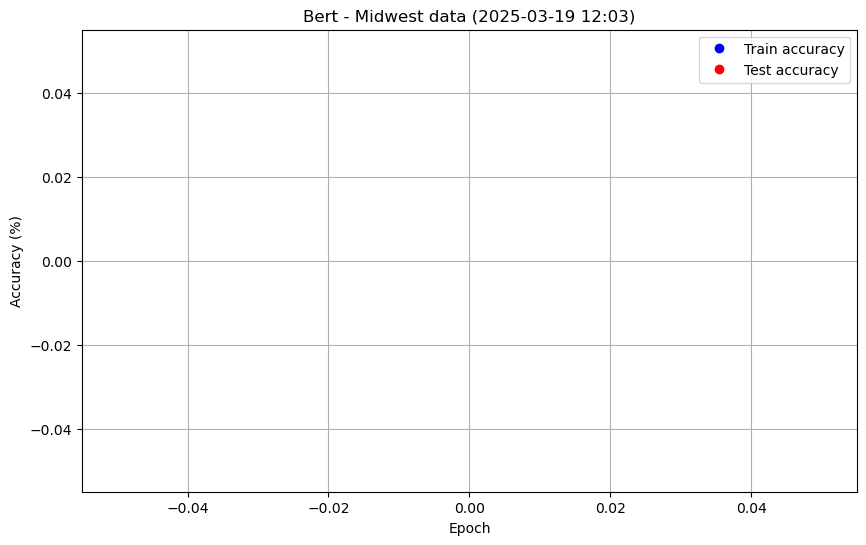

In [15]:
# Not sure how many is a good number for training. This takes *a long time*
epochs = 5

# Keep track of the accuracies to plot later
accs = [[], []] # 0 is train, 1 is test

for epoch in range(epochs):
    # Train mode
    model.train()
    total_loss = 0

    # Keep track of 
    correct_predictions = 0
    total_predictions = 0
    
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{epochs}"): # tqdm keeps track of progress
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        
        loss = outputs.loss
        total_loss += loss.item()
        
        loss.backward()
        
        optimizer.step()

        _, predicted_labels = torch.max(outputs.logits, dim=1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted_labels == labels).sum().item()

    accs[0].append(correct_predictions / total_predictions)
    
    ## Evaluation mode
    model.eval()
    
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for batch in test_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask)
            
            _, predicted_labels = torch.max(outputs.logits, dim=1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted_labels == labels).sum().item()

    accs[1].append(correct_predictions / total_predictions)
    
    print(f"Train loss: {(total_loss / len(train_dataloader)):.5f}, acc: {accs[0][epoch]:.4f} | Test acc: {accs[1][epoch]:.4f}")

# Auto plot the results upon completion. This also saves the test results as a png file
plot_lists_with_colors(accs[0], accs[1], label1="Train accuracy", label2="Test accuracy")

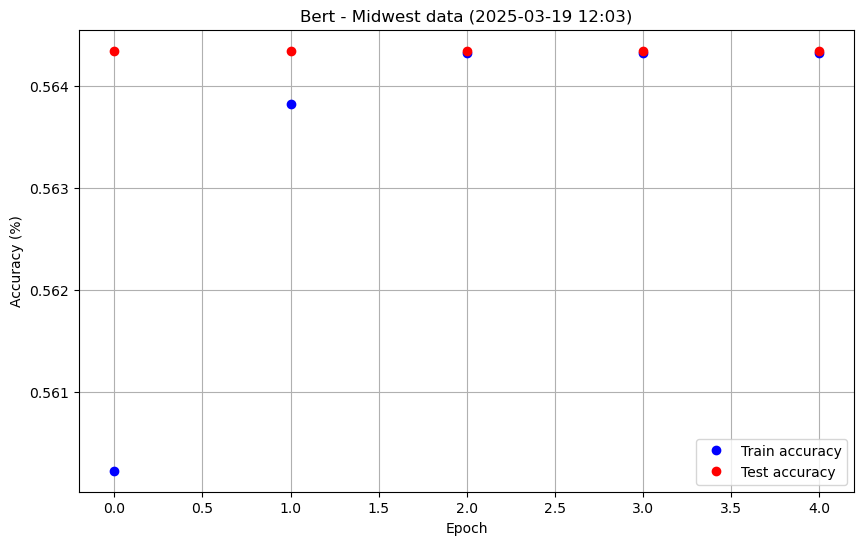

In [16]:
plot_lists_with_colors(accs[0], accs[1], label1="Train accuracy", label2="Test accuracy")